In [1]:
# the libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pandas as pd
import seaborn as sns
import cartopy.crs as ccrs
from scipy.stats import linregress



from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds


def build_weights(data, datadata, minvalue = -999, latlim = 90.):
    weights = datadata.isel(time = 0) > minvalue
    weights = weights *np.cos( np.deg2rad(data.lat))
    weights = weights*(abs(data.lat)<latlim)
    return weights

def anomaly(glbmean, weights, normalise = False, detrend = False):

    #nanoseconds per century required for fit
    ns_century = 1.e9*3600.*24.*365.*100.                # scaling: nono-seconds to century
    #detrend if desired
    if detrend:
        glbmean = glbmean.groupby('time.month').apply(detrend_monthly)

    
    databymth = glbmean.groupby("time.month")
    mthclim = databymth.mean("time")       # detrended climatological months (seasonal cycle)
    
    dataanom = databymth - mthclim          # detrended interannual annomaly
    if normalise:
        dataanom = dataanom/dataanom.std()
    dataanom = dataanom.rename('anom')   # change variable name
    return dataanom


def detrend_monthly(group):
    ns_century = 1.e9*3600.*24.*365.*100.
    linfit = group.polyfit('time', 1)
    slope = linfit.polyfit_coefficients.isel(degree=0) * ns_century

    trend = xr.polyval(coord=group.time, coeffs=linfit.polyfit_coefficients)
    detrended_group = group - trend.values + group.mean(dim='time')

    return detrended_group


def global_mean(data, datadata, weights):
    datadata_weighted = datadata.weighted(weights)
    weighted_mean = datadata_weighted.mean(('lat', 'lon'))
    return weighted_mean


In [3]:
# load nino
fp = '/data/jmex/output/drivers/indices/nino.nc'
nino = decode_time(fp)
ninoOND = nino.where(nino.time.dt.month.isin([10,11,12])).groupby('time.year').mean()
ninoJAS = nino.where(nino.time.dt.month.isin([7,8,9])).groupby('time.year').mean()
ninoJFM = nino.where(nino.time.dt.month.isin([1,2,3])).groupby('time.year').mean()

# SST part 

In [4]:
fp = '/data/jmex/ERA5/monthly/era5_tp.nc'
tp = decode_time(fp)#select rev. time only
#select revtime only
tp = tp.sel(time = slice('1958-01-01', '2023-12-31'))
#select west
tp_west = tp.sel(lat = slice(20,-20), lon = slice(130, 150))

tp_weights = np.cos(np.deg2rad(tp_west.lat))
tp_west_mean = global_mean(tp_west, tp_west.tp, tp_weights).rolling(time = 3, center = True).mean()


In [5]:
#compute the anomaly
tp_west_anom = anomaly(tp_west_mean, tp_weights, detrend = False)

tp_west['box_mean'] = tp_west_mean
tp_west['anom'] = tp_west_anom

In [4]:
fp = '/data/jmex/output/circulation/sst_dashed.nc'
sst_ = decode_time(fp)

In [5]:
#select western part
sst_west_ = sst_.sel(lat = slice(20,-20), lon = slice(130,150), time = slice('1958-01-01', '2023-12-31') )

#compute weighted average
sst_weights_ = np.cos(np.deg2rad(sst_west_.lat))
sst_west_mean_ = global_mean(sst_west_, sst_west_.sst_dashed, sst_weights_).rolling(time = 3, center = True).mean()

In [6]:
#compute the anomaly
sst_west_anom_ = anomaly(sst_west_mean_, sst_weights_, detrend = False)

sst_west_['box_mean'] = sst_west_mean_
sst_west_['anom'] = sst_west_anom_

In [9]:
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp)
#select western part
sst_west = sst.sel(lat = slice(20,-20), lon = slice(130,150), time = slice('1958-01-01', '2023-12-31') )

#compute weighted average
sst_weights = np.cos(np.deg2rad(sst_west.lat))
sst_west_mean = global_mean(sst_west, sst_west.sst, sst_weights).rolling(time = 3, center = True).mean()

In [10]:
#compute the anomaly
sst_west_anom = anomaly(sst_west_mean, sst_weights, detrend = False)

sst_west['box_mean'] = sst_west_mean
sst_west['anom'] = sst_west_anom

In [14]:
sst_west_.anom.std()

<xarray.DataArray 'anom' ()>
array(0.34493816)

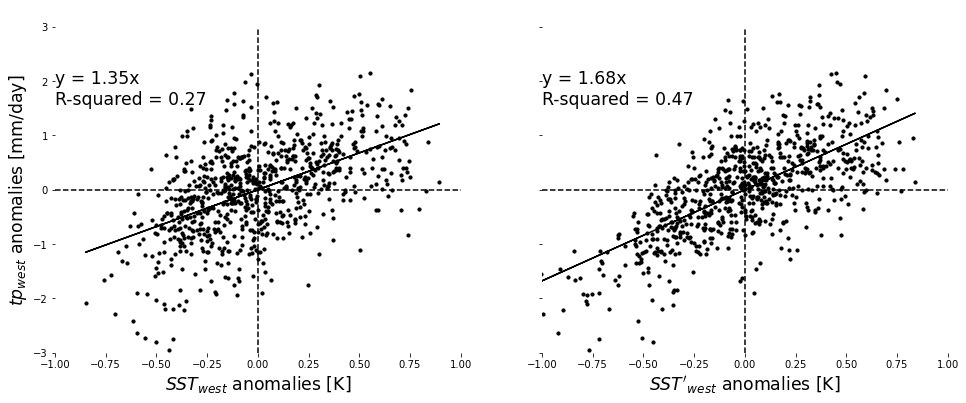

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Mask NaN values
valid_mask = ~np.isnan(sst_west.anom.values) & ~np.isnan(tp_west.anom.values)
sst_valid = sst_west.anom.values[valid_mask]
tp_valid = tp_west.anom.values[valid_mask]

# Perform linear regression for first plot
slope, intercept, r_value, p_value, std_err = linregress(sst_valid, tp_valid)

# Create figure and axes
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# First subplot
ax1 = axs[0]

# Create scatter plot
ax1.scatter(sst_valid, tp_valid, color='black', s=10)

# Add linear regression line
ax1.plot(sst_valid, slope * sst_valid + intercept, color='k')

# Add axis labels
ax1.set_xlabel(r'$SST_{west}$ anomalies [K]', fontweight = 'normal', fontsize = 'xx-large')
ax1.set_ylabel(r'$tp_{west}$ anomalies [mm/day]', fontweight = 'normal', fontsize = 'xx-large')

# Add title
ax1.set_title('')

# Add regression equation to the plot
ax1.text(-1, 1.5,
         f'y = {slope:.2f}x \nR-squared = {r_value**2:.2f}',
         color='black', verticalalignment='bottom', horizontalalignment='left', fontweight = 'normal', fontsize = 'xx-large' )

# Add dashed lines for x=0 and y=0
ax1.axvline(0, color='black', linestyle='--')
ax1.axhline(0, color='black', linestyle='--')

# Second subplot
ax2 = axs[1]

# Mask NaN values for second plot
valid_mask2 = ~np.isnan(sst_west_.anom.values) & ~np.isnan(tp_west.anom.values)
sst_valid2 = sst_west_.anom.values[valid_mask2]
tp_valid2 = tp_west.anom.values[valid_mask2]

# Perform linear regression for second plot
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(sst_valid2, tp_valid2)

# Create scatter plot for second plot
ax2.scatter(sst_valid2, tp_valid2, color='black', s=10)

# Add linear regression line for second plot
ax2.plot(sst_valid2, slope2 * sst_valid2 + intercept2, color='k')

# Add axis labels for second plot
ax2.set_xlabel(r"$SST'_{west}$ anomalies [K]", fontweight = 'normal', fontsize = 'xx-large')

# Add title for second plot
ax2.set_title(' ')

# Add regression equation to the second plot
ax2.text(-1, 1.5,
         f'y = {slope2:.2f}x \nR-squared = {r_value2**2:.2f}',
         color='black', verticalalignment='bottom', horizontalalignment='left',fontweight = 'normal', fontsize = 'xx-large')

# Add dashed lines for x=0 and y=0 for second plot
ax2.axvline(0, color='black', linestyle='--')
ax2.axhline(0, color='black', linestyle='--')

ax1.set_ylim(-3,3)

ax1.set_xlim(-1,1)
ax2.set_xlim(-1,1)


ax1.spines[:].set_visible(False)
ax2.spines[:].set_visible(False)


# Adjust layout
#plt.tight_layout()

# Show plots
plt.show()


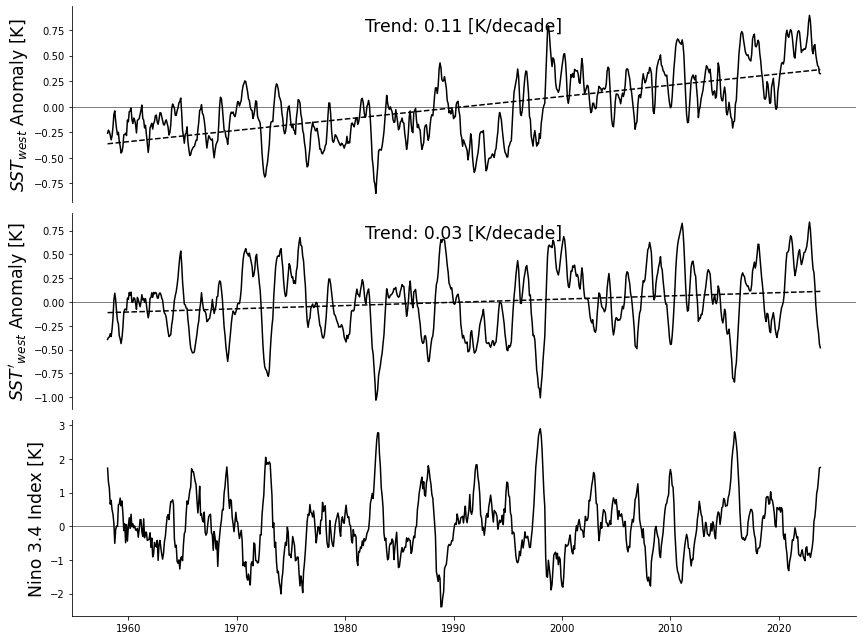

In [24]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

# Assuming you have already loaded your xarrays: sst_west_.anom and nino.nino34
valid_mask = ~np.isnan(nino.nino34) & ~np.isnan(sst_west_.anom)

# Create xarray datasets
sst_westanom = sst_west.anom[valid_mask]
sst_west_anom = sst_west_.anom[valid_mask]

nino_nino34 = nino.nino34[valid_mask]

time = nino_nino34.time


# Create the figure and subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Calculate trend in sst_west_.anom
trend = np.polyfit(np.arange(len(time)), sst_westanom, 1)
trend_line = np.polyval(trend, np.arange(len(time)))

# Plot SST anomaly
axs[0].plot(time, sst_westanom, color='black')
axs[0].plot(time, trend_line, color='black', linestyle='--')
axs[0].axhline(0, color='black', linewidth=0.5)
axs[0].set_ylabel(r"$SST_{west}$ Anomaly [K]", fontweight = 'normal', fontsize = 'xx-large')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['bottom'].set_visible(False)
axs[0].xaxis.set_visible(False)

# Show trend value
axs[0].text(0.5, 0.9, f'Trend: {10*12*trend[0]:.2f} [K/decade]', horizontalalignment='center', 
            verticalalignment='center', transform=axs[0].transAxes, fontsize = 'xx-large')


# Calculate trend in sst_west_.anom
trend = np.polyfit(np.arange(len(time)), sst_west_anom, 1)
trend_line = np.polyval(trend, np.arange(len(time)))


# Plot SST anomaly
axs[1].plot(time, sst_west_anom, color='black')
axs[1].plot(time, trend_line, color='black', linestyle='--')
axs[1].axhline(0, color='black', linewidth=0.5)
axs[1].set_ylabel(r"$SST'_{west}$ Anomaly [K]", fontweight = 'normal', fontsize = 'xx-large')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['bottom'].set_visible(False)
axs[1].xaxis.set_visible(False)

# Show trend value
axs[1].text(0.5, 0.9, f'Trend: {10*12*trend[0]:.2f} [K/decade]', horizontalalignment='center', 
            verticalalignment='center', transform=axs[1].transAxes, fontsize = 'xx-large')



# Plot Nino 3.4 index
axs[2].plot(time, nino_nino34, color='black')
axs[2].axhline(0, color='black', linewidth=0.5)
axs[2].set_ylabel('Nino 3.4 Index [K]', fontweight = 'normal', fontsize = 'xx-large')
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)


# Adjust layout
plt.tight_layout()

# Show plot
plt.show()


In [18]:
time

<xarray.DataArray 'time' (time: 790)>
array(['1958-02-01T00:00:00.000000000', '1958-03-01T00:00:00.000000000',
       '1958-04-01T00:00:00.000000000', ..., '2023-09-01T00:00:00.000000000',
       '2023-10-01T00:00:00.000000000', '2023-11-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 1958-02-01 1958-03-01 ... 2023-11-01
    month    (time) int64 ...

# Walker

In [7]:
fp = '/data/jmex/output/circulation/W_w500.nc'
W_w500 = xr.open_dataset(fp).sel(time = slice('1958', '2023'))

In [16]:
W_w500.w2w.std()

<xarray.DataArray 'w2w' ()>
array(0.60179677)

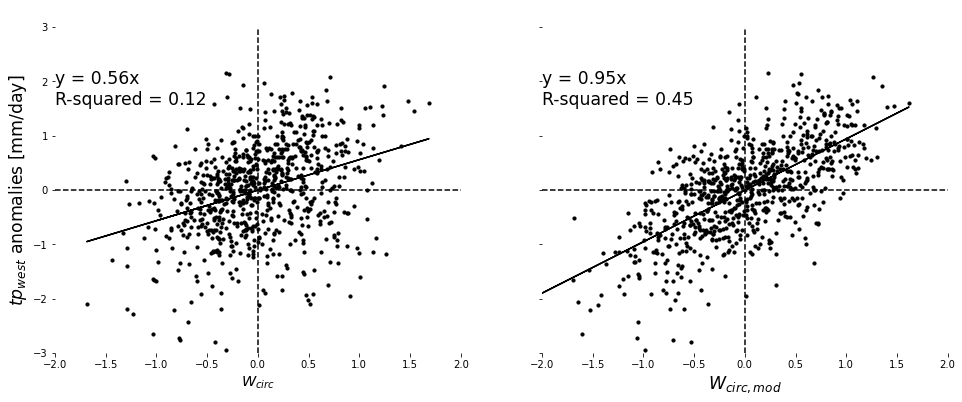

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Mask NaN values
valid_mask = ~np.isnan(W_w500.w2c.values) & ~np.isnan(tp_west.anom.values)
sst_valid = W_w500.w2c.values[valid_mask]
tp_valid = tp_west.anom.values[valid_mask]

# Perform linear regression for first plot
slope, intercept, r_value, p_value, std_err = linregress(sst_valid, tp_valid)

# Create figure and axes
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# First subplot
ax1 = axs[0]

# Create scatter plot
ax1.scatter(sst_valid, tp_valid, color='black', s=10)

# Add linear regression line
ax1.plot(sst_valid, slope * sst_valid + intercept, color='k')

# Add axis labels
ax1.set_xlabel(r'$W_{circ}$ ', fontweight = 'normal')
ax1.set_ylabel(r'$tp_{west}$ anomalies [mm/day]', fontweight = 'normal', fontsize = 'xx-large')

# Add title
ax1.set_title('')

# Add regression equation to the plot
ax1.text(-2, 1.5,
         f'y = {slope:.2f}x \nR-squared = {r_value**2:.2f}',
         color='black', verticalalignment='bottom', horizontalalignment='left', fontweight = 'normal' , fontsize = 'xx-large')

# Add dashed lines for x=0 and y=0
ax1.axvline(0, color='black', linestyle='--')
ax1.axhline(0, color='black', linestyle='--')

# Second subplot
ax2 = axs[1]

# Mask NaN values for second plot
valid_mask2 = ~np.isnan(W_w500.w2w.values) & ~np.isnan(tp_west.anom.values)
sst_valid2 = W_w500.w2w.values[valid_mask2]
tp_valid2 = tp_west.anom.values[valid_mask2]

# Perform linear regression for second plot
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(sst_valid2, tp_valid2)

# Create scatter plot for second plot
ax2.scatter(sst_valid2, tp_valid2, color='black', s=10)

# Add linear regression line for second plot
ax2.plot(sst_valid2, slope2 * sst_valid2 + intercept2, color='k')

# Add axis labels for second plot
ax2.set_xlabel(r"$W_{circ, mod}$", fontweight = 'normal', fontsize = 'xx-large')

# Add title for second plot
ax2.set_title(' ')

# Add regression equation to the second plot
ax2.text(-2, 1.5,
         f'y = {slope2:.2f}x \nR-squared = {r_value2**2:.2f}',
         color='black', verticalalignment='bottom', horizontalalignment='left',fontweight = 'normal', fontsize = 'xx-large')

# Add dashed lines for x=0 and y=0 for second plot
ax2.axvline(0, color='black', linestyle='--')
ax2.axhline(0, color='black', linestyle='--')

ax1.set_ylim(-3,3)

ax1.set_xlim(-2,2)
ax2.set_xlim(-2,2)


ax1.spines[:].set_visible(False)
ax2.spines[:].set_visible(False)


# Adjust layout
#plt.tight_layout()

# Show plots
plt.show()


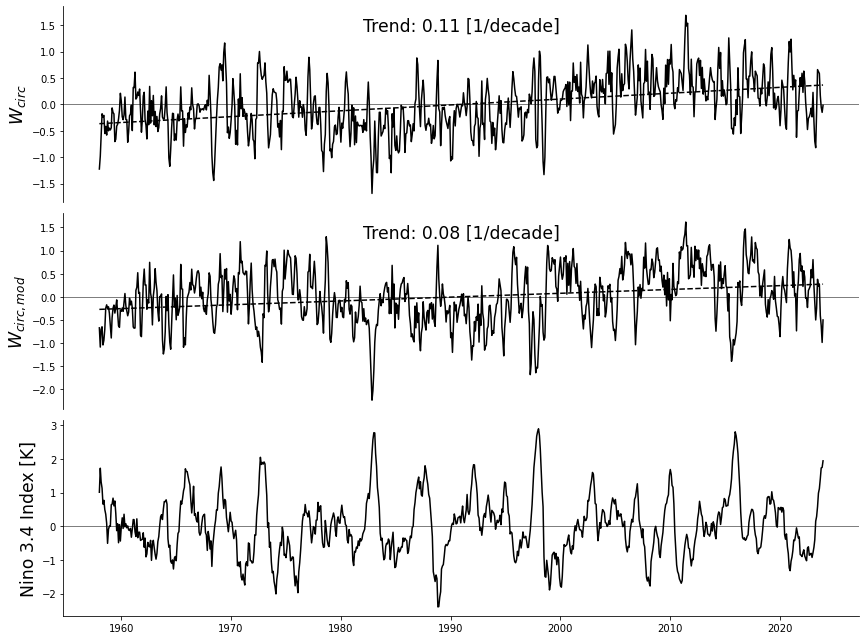

In [23]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

# Assuming you have already loaded your xarrays: W_w500.anom and nino.nino34
valid_mask = ~np.isnan(nino.nino34) & ~np.isnan(W_w500.w2w)

# Create xarray datasets
W_anom = W_w500.w2c[valid_mask]
Wc_anom = W_w500.w2w[valid_mask]
nino_nino34 = nino.nino34[valid_mask]

time = nino_nino34.time


# Create the figure and subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# Calculate trend in W_w500.anom
trend = np.polyfit(np.arange(len(time)), W_anom, 1)
trend_line = np.polyval(trend, np.arange(len(time)))

# Plot SST anomaly
axs[0].plot(time, W_anom, color='black')
axs[0].plot(time, trend_line, color='black', linestyle='--')
axs[0].axhline(0, color='black', linewidth=0.5)
axs[0].set_ylabel(r"$W_{circ}$", fontweight = 'normal', fontsize = 'xx-large')
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['bottom'].set_visible(False)
axs[0].xaxis.set_visible(False)

# Show trend value
axs[0].text(0.5, 0.9, f'Trend: {10*12*trend[0]:.2f} [1/decade]', horizontalalignment='center', 
            verticalalignment='center', transform=axs[0].transAxes, fontsize = 'xx-large')

# Calculate trend in W_w500.anom
trend = np.polyfit(np.arange(len(time)), Wc_anom, 1)
trend_line = np.polyval(trend, np.arange(len(time)))

# Plot SST anomaly
axs[1].plot(time, Wc_anom, color='black')
axs[1].plot(time, trend_line, color='black', linestyle='--')
axs[1].axhline(0, color='black', linewidth=0.5)
axs[1].set_ylabel(r"$W_{circ, mod}$", fontweight = 'normal', fontsize = 'xx-large')
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['bottom'].set_visible(False)
axs[1].xaxis.set_visible(False)
# Show trend value
axs[1].text(0.5, 0.9, f'Trend: {10*12*trend[0]:.2f} [1/decade]', horizontalalignment='center', 
            verticalalignment='center', transform=axs[1].transAxes, fontsize = 'xx-large')


# Plot Nino 3.4 index
axs[2].plot(time, nino_nino34, color='black')
axs[2].axhline(0, color='black', linewidth=0.5)
axs[2].set_ylabel('Nino 3.4 Index [K]', fontweight = 'normal', fontsize = 'xx-large')
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)


# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

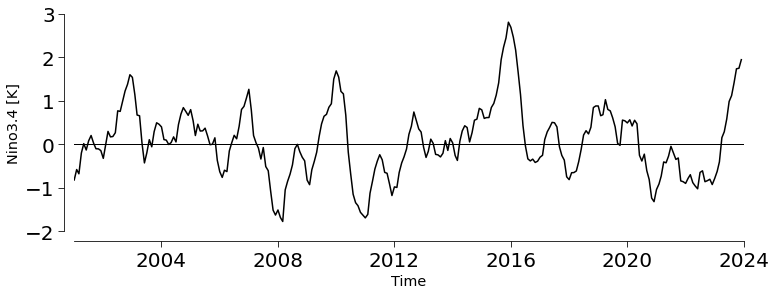

In [55]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Assuming 'nino' is your xarray dataset and 'nino3.4' is the data variable.
# You can load your dataset accordingly.
# nino = xr.open_dataset('your_dataset_path.nc')

# For demonstration, let's assume nino is already loaded and looks something like this:
# nino = xr.Dataset({'nino3.4': (['time'], np.random.randn(300))}, coords={'time': pd.date_range('1990-01-01', periods=300, freq='M')})

# Select the time range from 2001 to 2024
nino_subset = nino.sel(time=slice('2001', '2023'))

# Extract the data for plotting
time = nino_subset['time']
nino34_values = nino_subset['nino34']

# Create the plot
fig, ax = plt.subplots(figsize = (12,4))

ax.plot(time, nino34_values, label='Nino3.4 [K]', color = 'k')
ax.set_xlabel('Time', fontweight = 'normal')
ax.set_ylabel('Nino3.4 [K]', fontweight = 'normal')
ax.axhline(0, color='black', linewidth=1)  # Add the horizontal line at y=0

# Customize the ticks and limits
ax.tick_params(axis='x', direction='out', length=6)
ax.tick_params(axis='y', direction='out', length=6)
ax.set_ylim(-2, 3)

# Adjust the plot to ensure that x and y axes are not touching
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_tick_params(labelsize=20)
ax.yaxis.set_tick_params(labelsize=20)



ax.set_xlim(pd.Timestamp('2001-01-01'), pd.Timestamp('2024-01-01'))

#plt.legend()
plt.show()


In [14]:
valid_mask = ~np.isnan(sst_west_.anom)


In [17]:
np.corrcoef(W_w500.w2w[valid_mask],sst_west_.anom[valid_mask])**2

array([[1.        , 0.35663792],
       [0.35663792, 1.        ]])

In [16]:
W_w500.w2w

<xarray.DataArray 'w2w' (time: 792)>
array([-0.670322, -1.086864, -0.707746, ..., -0.62275 , -0.986214, -0.50005 ])
Coordinates:
  * time     (time) datetime64[ns] 1958-01-01 1958-02-01 ... 2023-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12